# Airbnb vs Hotel Impact Analysis

## Objective
Analyze how Airbnb listings impact hotels using real-world data.

## Data Sources

In [115]:
import os
os.getcwd()

'C:\\Users\\user\\OneDrive\\Documents\\airbnb-hotel-impact\\data\\Notebooks'

In [117]:
import os

os.listdir("../raw")

['airbnb', 'hotels']

In [119]:
os.listdir("../raw/airbnb")

['Chicago', 'Los Angeles', 'New York City', 'San Francisco', 'Seattle']

## Chicago Airbnb vs Hotel Impact Analysis

In [122]:
os.listdir("../raw/airbnb/Chicago")

['CHI-calendar.csv',
 'CHI-listings.csv',
 'CHI-listings_detailed.csv',
 'CHI-neighbourhoods.csv',
 'CHI-reviews.csv',
 'CHI-reviews_detailed.csv',
 'neighbourhoods.geojson']

In [124]:
os.listdir("../raw/hotels")

['Chicago', 'Los Angeles', 'New York City', 'San Francisco', 'Seattle']

In [126]:
import pandas as pd

chi_airbnb = pd.read_csv("../raw/airbnb/Chicago/CHI-listings.csv")
chi_airbnb.shape

(7747, 18)

In [128]:
chi_airbnb.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')

In [130]:
chi_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2384,Hyde Park - Walk to UChicago,2613,Rebecca,NaN,Hyde Park,41.78790,-87.58780,Private room,90,3,212,2023-03-04,2.13,1,347,20,R17000015609
1,94450,Comfy Garden Suite in Andersonville,504470,Mark,NaN,Edgewater,41.97960,-87.66512,Entire home/apt,65,7,7,2022-12-01,0.88,1,178,7,R22000082956
2,145659,Trendy Roscoe Village 3BR/2BR walk to shops,683529,Joe,NaN,North Center,41.94342,-87.68121,Entire home/apt,198,2,59,2022-12-31,0.65,22,330,15,2209272
3,7126,Tiny Studio Apartment 94 Walk Score,17928,Sarah,NaN,West Town,41.90166,-87.68021,Entire home/apt,85,2,483,2023-02-26,2.89,1,279,48,R21000075737
4,189821,"Best in Chicago, private, amazing garden space",899757,Meighan,NaN,Logan Square,41.92918,-87.70219,Entire home/apt,202,3,598,2023-02-25,4.27,1,207,24,R21000062936


In [132]:
chi_airbnb.isna().sum()

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group               7747
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       1493
reviews_per_month                 1493
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           1174
dtype: int64

In [134]:
# Drop useless column
chi_airbnb = chi_airbnb.drop(columns=["neighbourhood_group"])

# Convert dates
chi_airbnb["last_review"] = pd.to_datetime(chi_airbnb["last_review"])

# Fill review rate NaNs with 0 (no reviews)
chi_airbnb["reviews_per_month"] = chi_airbnb["reviews_per_month"].fillna(0)

chi_airbnb.isna().sum()

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       1493
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           1174
dtype: int64

In [136]:
chi_airbnb["room_type"].value_counts()

room_type
Entire home/apt    6036
Private room       1589
Shared room          72
Hotel room           50
Name: count, dtype: int64

In [138]:
chi_airbnb.loc[chi_airbnb["last_review"].isna(), ["number_of_reviews", "reviews_per_month"]].head(10)

,number_of_reviews,reviews_per_month
73,0,0.0
142,0,0.0
335,0,0.0
385,0,0.0
445,0,0.0
474,0,0.0
513,0,0.0
518,0,0.0
527,0,0.0
577,0,0.0


### Data Cleaning Notes

- Listings with no reviews have missing `last_review` values.
- These missing values are expected and indicate no customer reviews.
- `reviews_per_month` was filled with 0 for such listings.
- No artificial dates were introduced to preserve data integrity.

In [141]:
# Keep a clean copy for analysis
chi_airbnb_clean = chi_airbnb.copy()

# Ensure correct data types
chi_airbnb_clean["last_review"] = pd.to_datetime(
    chi_airbnb_clean["last_review"], errors="coerce"
)

# Reviews per month: no reviews → 0
chi_airbnb_clean["reviews_per_month"] = (
    chi_airbnb_clean["reviews_per_month"].fillna(0)
)

# Helpful binary feature
chi_airbnb_clean["has_reviews"] = chi_airbnb_clean["number_of_reviews"] > 0

chi_airbnb_clean.isna().sum()

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       1493
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           1174
has_reviews                          0
dtype: int64

In [143]:
import os
os.makedirs("../processed", exist_ok=True)

In [145]:
chi_airbnb_clean.to_csv(
    "../processed/chicago_airbnb_clean.csv",
    index=False
)

In [147]:
chi_airbnb_clean["price"].describe()

count     7747.000000
mean       184.285917
std       1160.005899
min          0.000000
25%         77.000000
50%        124.000000
75%        189.000000
max      99998.000000
Name: price, dtype: float64

In [149]:
chi_airbnb_clean[chi_airbnb_clean["price"] < 1000]["price"].describe()

count    7666.000000
mean      155.459170
std       127.698937
min         0.000000
25%        77.000000
50%       122.000000
75%       185.000000
max       999.000000
Name: price, dtype: float64

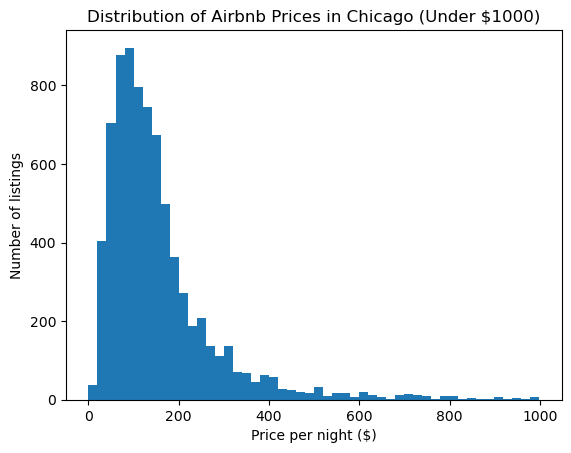

In [151]:
import matplotlib.pyplot as plt

plt.hist(
    chi_airbnb_clean[chi_airbnb_clean["price"] < 1000]["price"],
    bins=50
)
plt.xlabel("Price per night ($)")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb Prices in Chicago (Under $1000)")
plt.show()

In [153]:
chi_airbnb_clean.groupby("room_type")["price"].median()

room_type
Entire home/apt    140.0
Hotel room         173.0
Private room        55.0
Shared room         29.0
Name: price, dtype: float64

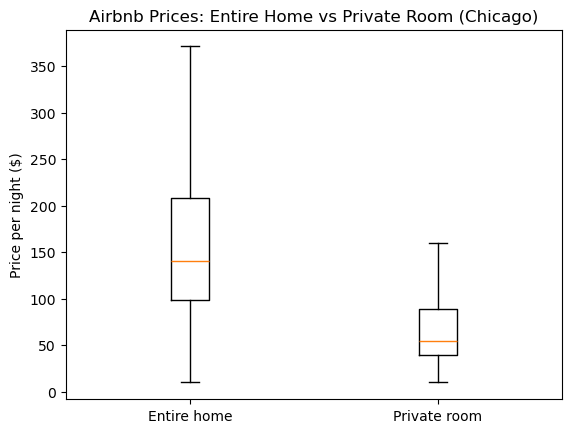

In [155]:
import matplotlib.pyplot as plt

room_prices = (
    chi_airbnb_clean
    .loc[chi_airbnb_clean["room_type"].isin(["Entire home/apt", "Private room"])]
)

plt.boxplot(
    [
        room_prices[room_prices["room_type"] == "Entire home/apt"]["price"],
        room_prices[room_prices["room_type"] == "Private room"]["price"]
    ],
    tick_labels=["Entire home", "Private room"]
,
    showfliers=False
)

plt.ylabel("Price per night ($)")
plt.title("Airbnb Prices: Entire Home vs Private Room (Chicago)")
plt.show()

In [157]:
import pandas as pd

chi_hotels_wages = pd.read_excel(
    "../raw/hotels/Chicago/hotels_wages_chicago.xlsx"
)

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [159]:
chi_hotels_wages.shape

(24, 6)

In [161]:
chi_hotels_wages.head()

,Quarterly Census of Employment and Wages,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Original Data Value,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Series Id:,ENUC169830572111,NaN,NaN,NaN,NaN
3,Series Title:,Total Wages (in thousands) in Private NAICS 72...,NaN,NaN,NaN,NaN
4,State:,Metropolitan Area Groupings,NaN,NaN,NaN,NaN


In [163]:
chi_hotels_wages.columns

Index(['Quarterly Census of Employment and Wages', 'Unnamed: 1', 'Unnamed: 2',
       'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5'],
      dtype='object')

In [165]:
chi_hotels_wages

,Quarterly Census of Employment and Wages,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Original Data Value,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Series Id:,ENUC169830572111,NaN,NaN,NaN,NaN
3,Series Title:,Total Wages (in thousands) in Private NAICS 72...,NaN,NaN,NaN,NaN
4,State:,Metropolitan Area Groupings,NaN,NaN,NaN,NaN
5,Area:,"Chicago-Naperville-Elgin, IL-IN MSA",NaN,NaN,NaN,NaN
6,Industry:,NAICS 72111 Hotels (except casino hotels) and ...,NaN,NaN,NaN,NaN
7,Owner:,Private,NaN,NaN,NaN,NaN
8,Size:,All establishment sizes,NaN,NaN,NaN,NaN
9,Type:,Total Wages (in thousands),NaN,NaN,NaN,NaN


In [167]:
chi_hotels_wages.tail()

,Quarterly Census of Employment and Wages,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
19,2020,NaN,NaN,NaN,NaN,869722
20,2021,NaN,NaN,NaN,NaN,982423
21,2022,NaN,NaN,NaN,NaN,1499942
22,2023,NaN,NaN,NaN,NaN,1692234
23,2024,NaN,NaN,NaN,NaN,NaN


In [169]:
chi_hotels_wages_clean = pd.read_excel(
    "../raw/hotels/Chicago/hotels_wages_chicago.xlsx",
    header=12
)

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [171]:
chi_hotels_wages_clean = chi_hotels_wages_clean.rename(
    columns={"Unnamed: 0": "Year", "Unnamed: 5": "Annual"}
)

chi_hotels_wages_clean = chi_hotels_wages_clean[["Year", "Annual"]].copy()

# convert to numbers safely
chi_hotels_wages_clean["Year"] = pd.to_numeric(chi_hotels_wages_clean["Year"], errors="coerce")
chi_hotels_wages_clean["Annual"] = pd.to_numeric(chi_hotels_wages_clean["Annual"], errors="coerce")

# keep only real years + real annual values
chi_hotels_wages_clean = chi_hotels_wages_clean.dropna(subset=["Year", "Annual"])
chi_hotels_wages_clean["Year"] = chi_hotels_wages_clean["Year"].astype(int)

chi_hotels_wages_clean.head()

,Year,Annual
1,2014,1252848.0
2,2015,1449243.0
3,2016,1454926.0
4,2017,1514772.0
5,2018,1598462.0


In [173]:
chi_hotels_wages_clean.dtypes

Year        int32
Annual    float64
dtype: object

In [175]:
chi_hotels_wages_clean = chi_hotels_wages_clean.rename(
    columns={
        "Year": "year",
        "Annual": "hotel_wages_thousands"
    }
)

In [177]:
chi_hotels_wages_clean.head()

,year,hotel_wages_thousands
1,2014,1252848.0
2,2015,1449243.0
3,2016,1454926.0
4,2017,1514772.0
5,2018,1598462.0


In [179]:
chi_airbnb_clean.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'number_of_reviews_ltm', 'license', 'has_reviews'],
      dtype='object')

In [181]:
chi_airbnb_clean

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,has_reviews
0,2384,Hyde Park - Walk to UChicago,2613,Rebecca,Hyde Park,41.787900,-87.587800,Private room,90,3,212,2023-03-04,2.13,1,347,20,R17000015609,True
1,94450,Comfy Garden Suite in Andersonville,504470,Mark,Edgewater,41.979600,-87.665120,Entire home/apt,65,7,7,2022-12-01,0.88,1,178,7,R22000082956,True
2,145659,Trendy Roscoe Village 3BR/2BR walk to shops,683529,Joe,North Center,41.943420,-87.681210,Entire home/apt,198,2,59,2022-12-31,0.65,22,330,15,2209272,True
3,7126,Tiny Studio Apartment 94 Walk Score,17928,Sarah,West Town,41.901660,-87.680210,Entire home/apt,85,2,483,2023-02-26,2.89,1,279,48,R21000075737,True
4,189821,"Best in Chicago, private, amazing garden space",899757,Meighan,Logan Square,41.929180,-87.702190,Entire home/apt,202,3,598,2023-02-25,4.27,1,207,24,R21000062936,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7742,807864161683006482,Chicago Summer Backyard Fun,112243295,Mike,Irving Park,41.952694,-87.740631,Entire home/apt,301,7,0,NaT,0.00,1,99,0,R23000096712,False
7743,807880884094680264,"Loop 1br w/ pool, gym & lounge, nr Riverwalk",107434423,Blueground,Loop,41.886081,-87.634222,Entire home/apt,156,32,0,NaT,0.00,658,229,0,NaN,False
7744,808048225308192110,Stunning 2 Floor Penthouse Downtown - Sleeps 12,170785489,Dmd,West Town,41.900671,-87.658671,Entire home/apt,351,1,3,2023-03-09,3.00,39,334,3,2637371,True
7745,808067261823221295,Fully furnished 2BR w/ Cozy Living Room & Wi-Fi!,490752114,Sevyn,Rogers Park,42.016381,-87.665129,Entire home/apt,81,1,2,2023-03-12,1.58,9,169,2,R22000094683,True


In [183]:
chi_airbnb_clean["year"] = pd.to_datetime(
    chi_airbnb_clean["last_review"],
    errors="coerce"
).dt.year

In [185]:
chi_airbnb_clean[["last_review", "year"]].head()

,last_review,year
0,2023-03-04,2023.0
1,2022-12-01,2022.0
2,2022-12-31,2022.0
3,2023-02-26,2023.0
4,2023-02-25,2023.0


In [187]:
airbnb_yearly = (
    chi_airbnb_clean
        .dropna(subset=["year"])     # remove rows without a year
        .groupby("year")             # group listings by year
        .agg(
            median_price=("price", "median"),
            listing_count=("id", "count")
        )
        .reset_index()
)

In [189]:
airbnb_yearly

,year,median_price,listing_count
0,2014.0,153.0,1
1,2015.0,177.5,4
2,2016.0,156.0,20
3,2017.0,99.5,38
4,2018.0,90.0,73
5,2019.0,103.5,158
6,2020.0,99.0,192
7,2021.0,125.0,297
8,2022.0,121.0,1950
9,2023.0,114.0,3521


In [191]:
airbnb_yearly["year"] = airbnb_yearly["year"].astype(int)

In [193]:
airbnb_yearly.dtypes

year               int32
median_price     float64
listing_count      int64
dtype: object

In [195]:
airbnb_yearly.columns
chi_hotels_wages_clean.columns

Index(['year', 'hotel_wages_thousands'], dtype='object')

In [197]:
chi_hotels_wages_clean.head(20)

,year,hotel_wages_thousands
1,2014,1252848.0
2,2015,1449243.0
3,2016,1454926.0
4,2017,1514772.0
5,2018,1598462.0
6,2019,1692781.0
7,2020,869722.0
8,2021,982423.0
9,2022,1499942.0
10,2023,1692234.0


In [203]:
chi_combined = pd.merge(
    airbnb_yearly,
    chi_hotels_wages_clean,
    on="year",
    how="inner"
)

chi_combined.head()

,year,median_price,listing_count,hotel_wages_thousands
0,2014,153.0,1,1252848.0
1,2015,177.5,4,1449243.0
2,2016,156.0,20,1454926.0
3,2017,99.5,38,1514772.0
4,2018,90.0,73,1598462.0


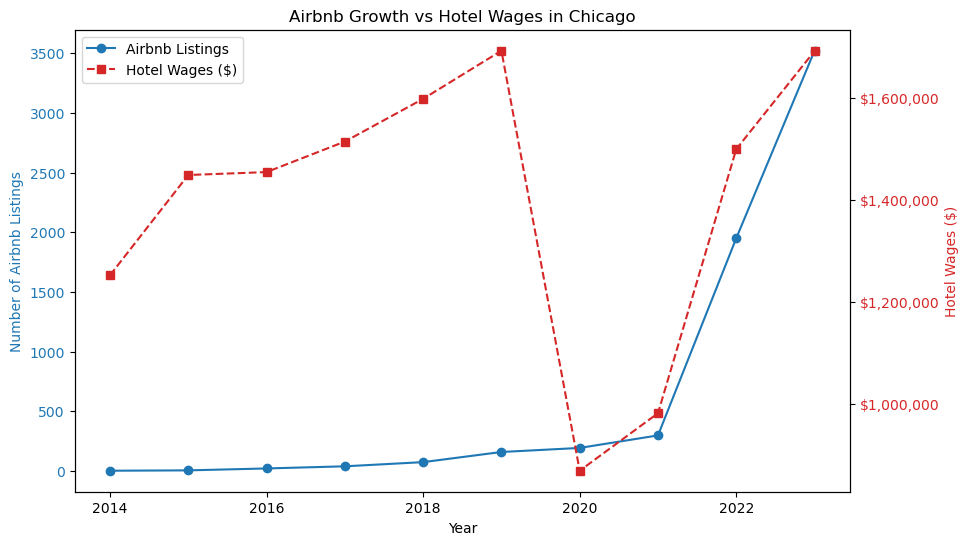

In [205]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax1 = plt.subplots(figsize=(10, 6))

# Airbnb listings (LEFT axis)
airbnb_line, = ax1.plot(
    chi_combined["year"],
    chi_combined["listing_count"],
    color="tab:blue",
    marker="o",
    label="Airbnb Listings"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Airbnb Listings", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Hotel wages (RIGHT axis)
ax2 = ax1.twinx()
hotel_line, = ax2.plot(
    chi_combined["year"],
    chi_combined["hotel_wages_thousands"],
    color="tab:red",
    marker="s",
    linestyle="--",
    label="Hotel Wages ($)"
)
ax2.set_ylabel("Hotel Wages ($)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Remove scientific notation
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"${int(x):,}")
)

# Title
plt.title("Airbnb Growth vs Hotel Wages in Chicago")

# Combined legend
lines = [airbnb_line, hotel_line]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.show()

### Chicago Case Study: Airbnb Growth vs Hotel Industry Wages

To evaluate the potential impact of Airbnb expansion on the traditional hotel industry, we compare the growth of Airbnb listings in Chicago with total wages paid within the hotel sector.

The visualization shows two key trends between 2014 and 2023. First, Airbnb listings increased dramatically over the period, especially after 2021, indicating rapid growth in short-term rental supply. Second, total hotel wages generally increased from 2014 to 2019, reflecting steady growth in the hotel industry prior to the COVID-19 pandemic.

A sharp decline in hotel wages is visible in 2020, corresponding to the pandemic's severe disruption of the travel and hospitality sector. Following this shock, hotel wages begin to recover, although Airbnb listings continue to grow at a much faster rate.

While this comparison does not establish a direct causal relationship, it highlights how the rapid expansion of the short-term rental market occurred alongside major structural changes in the traditional hotel industry. The comparison provides a useful macro-level perspective on how emerging platform-based accommodation markets may reshape the broader hospitality landscape.  

## Seattle Airbnb vs Hotel Impact Analysis

In this section, we repeat the same analysis pipeline for Seattle.
We will:
- Load Seattle Airbnb data
- Aggregate listings by year
- Merge with Seattle hotel wages
- Visualize the relationship

In [209]:
import pandas as pd

seattle_airbnb = pd.read_csv("../raw/airbnb/Seattle/Seattle-listings.csv")
seattle_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,879181,In Jimi Hendrix's neighborhood 3,287172,Laura,Central Area,Atlantic,47.60096,-122.30190,Private room,53,30,99,2022-12-16,0.80,2,247,4,STR-OPLI-19-002301
1,6606,"Fab, private seattle urban cottage!",14942,Joyce,Other neighborhoods,Wallingford,47.65444,-122.33629,Entire home/apt,99,30,159,2022-09-03,0.95,3,99,2,str-opli-19-002622
2,902609,Entire guest suite in West Seattle,3264544,Fabio,Delridge,Highland Park,47.52383,-122.35287,Entire home/apt,70,2,238,2023-03-21,1.95,5,206,27,STR-OPLI-19-002360
3,9419,Glorious sun room w/ memory foambed,30559,Angielena,Other neighborhoods,Georgetown,47.55017,-122.31937,Private room,55,2,175,2023-01-15,1.14,9,356,20,STR-OPLI-19-003039
4,226536,Serene Room in Sunny Cottage near Discovery Park,209571,Cheryl,Magnolia,Lawton Park,47.66133,-122.40088,Private room,61,1,316,2022-12-12,2.28,1,209,53,STR-OPLI-19-000684


In [211]:
seattle_airbnb.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')

In [213]:
seattle_airbnb["year"] = pd.to_datetime(
    seattle_airbnb["last_review"],
    errors="coerce"
).dt.year

seattle_airbnb[["last_review", "year"]].head()

,last_review,year
0,2022-12-16,2022.0
1,2022-09-03,2022.0
2,2023-03-21,2023.0
3,2023-01-15,2023.0
4,2022-12-12,2022.0


In [215]:
seattle_yearly = (
    seattle_airbnb
        .dropna(subset=["year"])
        .groupby("year")
        .agg(
            median_price=("price", "median"),
            listing_count=("id", "count")
        )
        .reset_index()
)

seattle_yearly.head()

,year,median_price,listing_count
0,2013.0,232.0,1
1,2014.0,260.5,2
2,2015.0,125.0,3
3,2016.0,166.5,8
4,2017.0,124.0,6


In [217]:
import pandas as pd

seattle_hotels_wages = pd.read_excel(
    "../raw/hotels/Seattle/hotels_wages_seattle.xlsx",
    header=None
)

seattle_hotels_wages.head(20)

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0,1,2,3,4,5
0,Quarterly Census of Employment and Wages,NaN,NaN,NaN,NaN,NaN
1,Original Data Value,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,Series Id:,ENUC426630572111,NaN,NaN,NaN,NaN
4,Series Title:,Total Wages (in thousands) in Private NAICS 72...,NaN,NaN,NaN,NaN
5,State:,Metropolitan Area Groupings,NaN,NaN,NaN,NaN
6,Area:,"Seattle-Tacoma-Bellevue, WA MSA",NaN,NaN,NaN,NaN
7,Industry:,NAICS 72111 Hotels (except casino hotels) and ...,NaN,NaN,NaN,NaN
8,Owner:,Private,NaN,NaN,NaN,NaN
9,Size:,All establishment sizes,NaN,NaN,NaN,NaN


In [219]:
seattle_hotels_clean = seattle_hotels_wages.iloc[13:, :]

In [221]:
seattle_hotels_clean.columns = seattle_hotels_clean.iloc[0]

In [223]:
seattle_hotels_clean = seattle_hotels_clean.iloc[1:]

In [225]:
seattle_hotels_clean = seattle_hotels_clean[["Year", "Annual"]]

In [227]:
seattle_hotels_clean.columns = ["year", "hotel_wages_thousands"]

In [229]:
seattle_hotels_clean.tail()

,year,hotel_wages_thousands
20,2020,NaN
21,2021,NaN
22,2022,NaN
23,2023,767345
24,2024,818232


In [231]:
seattle_hotels_clean = seattle_hotels_clean.dropna()

In [233]:
seattle_hotels_clean["year"] = seattle_hotels_clean["year"].astype(int)
seattle_hotels_clean["hotel_wages_thousands"] = seattle_hotels_clean["hotel_wages_thousands"].astype(int)

In [235]:
seattle_hotels_clean

,year,hotel_wages_thousands
23,2023,767345
24,2024,818232


In [237]:
seattle_hotels_clean.head()

,year,hotel_wages_thousands
23,2023,767345
24,2024,818232


In [239]:
seattle_hotels_clean.shape

(2, 2)

In [241]:
seattle_hotels_wages.tail(15)

,0,1,2,3,4,5
10,Type:,Total Wages (in thousands),NaN,NaN,NaN,NaN
11,Years:,2014 to 2024,NaN,NaN,NaN,NaN
12,NaN,NaN,NaN,NaN,NaN,NaN
13,Year,Qtr1,Qtr2,Qtr3,Qtr4,Annual
14,2014,NaN,NaN,NaN,NaN,NaN
15,2015,NaN,NaN,NaN,NaN,NaN
16,2016,NaN,NaN,NaN,NaN,NaN
17,2017,NaN,NaN,NaN,NaN,NaN
18,2018,NaN,NaN,NaN,NaN,NaN
19,2019,NaN,NaN,NaN,NaN,NaN


In [243]:
seattle_hotels_wages.iloc[13:, 5].isna().sum()

9

In [245]:
seattle_hotels_wages.loc[13:, [0, 5]].dropna()

,0,5
13,Year,Annual
23,2023,767345
24,2024,818232


In [247]:
seattle_combined = pd.merge(
    seattle_yearly,
    seattle_hotels_clean,
    on="year",
    how="inner"
)

seattle_combined

,year,median_price,listing_count,hotel_wages_thousands
0,2023.0,125.0,3406,767345


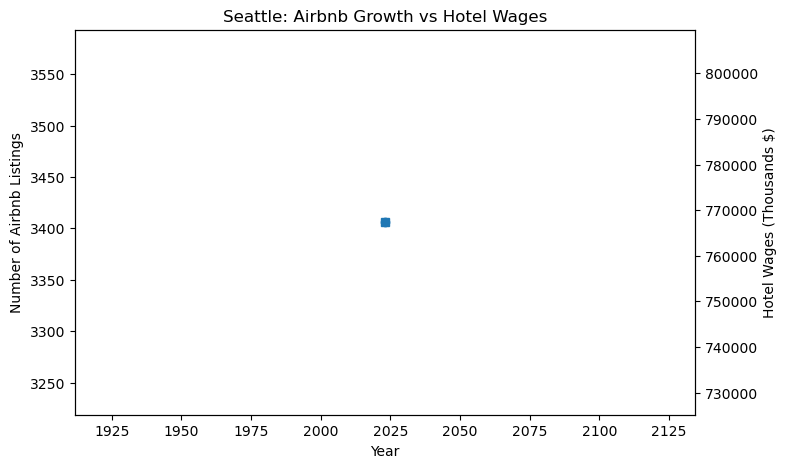

In [249]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8,5))

# Airbnb Listings (left axis)
ax1.plot(
    seattle_combined["year"],
    seattle_combined["listing_count"],
    marker="o"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Airbnb Listings")

# Second axis for hotel wages
ax2 = ax1.twinx()

ax2.plot(
    seattle_combined["year"],
    seattle_combined["hotel_wages_thousands"],
    linestyle="--",
    marker="s"
)
ax2.set_ylabel("Hotel Wages (Thousands $)")

plt.title("Seattle: Airbnb Growth vs Hotel Wages")
plt.show()

## Methodological Adjustment: From Total Wages to Average Pay

While total hotel wages provide insight into overall industry size, they do not isolate compensation effects. Total wages are influenced by both employment levels and pay rates, making causal interpretation more complex.

To better evaluate wage-level trends in the hotel industry, we transition to **Average Annual Pay**, which serves as a more direct proxy for worker earnings.

This adjustment improves analytical clarity and supports a more precise comparison with Airbnb growth dynamics.


In [252]:
import pandas as pd

seattle_annualpay = pd.read_excel(
    "../raw/hotels/Seattle/hotels_average_annualpay_seattle.xlsx",
    header=None
)

seattle_annualpay.head(20)

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0,1
0,Quarterly Census of Employment and Wages,NaN
1,Original Data Value,NaN
2,NaN,NaN
3,Series Id:,ENUC426650572111
4,Series Title:,Average Annual Pay in Private NAICS 72111 Hote...
5,State:,Metropolitan Area Groupings
6,Area:,"Seattle-Tacoma-Bellevue, WA MSA"
7,Industry:,NAICS 72111 Hotels (except casino hotels) and ...
8,Owner:,Private
9,Size:,All establishment sizes


In [254]:
seattle_annualpay.tail(20)

,0,1
5,State:,Metropolitan Area Groupings
6,Area:,"Seattle-Tacoma-Bellevue, WA MSA"
7,Industry:,NAICS 72111 Hotels (except casino hotels) and ...
8,Owner:,Private
9,Size:,All establishment sizes
10,Type:,Average Annual Pay
11,Years:,2014 to 2024
12,NaN,NaN
13,Year,Annual
14,2014,NaN


In [256]:
seattle_annualpay.iloc[13:25]

,0,1
13,Year,Annual
14,2014,NaN
15,2015,NaN
16,2016,NaN
17,2017,NaN
18,2018,NaN
19,2019,NaN
20,2020,NaN
21,2021,NaN
22,2022,NaN


In [258]:
seattle_annualpay.shape
seattle_annualpay.columns

Index([0, 1], dtype='int64')

In [260]:
import pandas as pd

pd.ExcelFile("../raw/hotels/Seattle/hotels_average_annualpay_seattle.xlsx").sheet_names

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


['BLS Data Series']

In [262]:
seattle_annualpay.iloc[12:26, :10]

,0,1
12,NaN,NaN
13,Year,Annual
14,2014,NaN
15,2015,NaN
16,2016,NaN
17,2017,NaN
18,2018,NaN
19,2019,NaN
20,2020,NaN
21,2021,NaN


In [264]:
pd.ExcelFile("../raw/hotels/Seattle/hotels_average_annualpay_seattle.xlsx").sheet_names
seattle_annualpay.shape
seattle_annualpay.head(20)

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0,1
0,Quarterly Census of Employment and Wages,NaN
1,Original Data Value,NaN
2,NaN,NaN
3,Series Id:,ENUC426650572111
4,Series Title:,Average Annual Pay in Private NAICS 72111 Hote...
5,State:,Metropolitan Area Groupings
6,Area:,"Seattle-Tacoma-Bellevue, WA MSA"
7,Industry:,NAICS 72111 Hotels (except casino hotels) and ...
8,Owner:,Private
9,Size:,All establishment sizes


### Seattle Case Study: Data Availability Limitation

We attempted to replicate the same analysis performed for Chicago by comparing Airbnb listing growth with hotel industry wage data for the Seattle metropolitan area.

However, the available BLS QCEW dataset for Seattle contains substantial data suppression. Most years in the series do not report values for either total hotel wages or average annual pay. Only the most recent years (2023–2024) contain usable values.

Because a meaningful time-series comparison requires multiple years of consistent observations, this dataset does not provide enough information to analyze long-term trends between Airbnb growth and hotel industry wages in Seattle.

As a result, Seattle cannot support the same level of comparative analysis performed for Chicago. This limitation highlights a common challenge when working with real-world government datasets, where confidentiality protections often suppress detailed industry data for certain regions or time periods.

Future analysis could explore alternative indicators of hotel industry activity, such as employment levels or establishment counts, if more complete datasets become available.

## New York Airbnb vs Hotel Impact Analysis

In [268]:
import pandas as pd

# Load NYC Airbnb listings dataset
nyc_airbnb = pd.read_csv(
    "../raw/airbnb/New York City/nyc-listings.csv")
nyc_airbnb.head()

C:\Users\user\AppData\Local\Temp\ipykernel_7628\3072535286.py:4: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  nyc_airbnb = pd.read_csv(


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75356,-73.98559,Entire home/apt,150,30,49,2022-06-21,0.30,3,314,1,NaN
1,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68535,-73.95512,Private room,60,30,50,2019-12-02,0.30,2,365,0,NaN
2,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80380,-73.96751,Private room,75,2,118,2017-07-21,0.72,1,0,0,NaN
3,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Midtown,40.76457,-73.98317,Private room,68,2,575,2023-02-19,3.41,1,106,52,NaN
4,5136,"Large Sunny Brooklyn Duplex, Patio + Garden",7378,Rebecca,Brooklyn,Sunset Park,40.66265,-73.99454,Entire home/apt,275,60,3,2022-08-10,0.03,1,181,1,NaN


In [270]:
# Convert last_review to datetime
nyc_airbnb["last_review"] = pd.to_datetime(nyc_airbnb["last_review"])

# Create year column
nyc_airbnb["year"] = nyc_airbnb["last_review"].dt.year

# Check result
nyc_airbnb[["last_review","year"]].head()

,last_review,year
0,2022-06-21,2022.0
1,2019-12-02,2019.0
2,2017-07-21,2017.0
3,2023-02-19,2023.0
4,2022-08-10,2022.0


In [272]:
nyc_hotel_wages = pd.read_excel(
    "../raw/hotels/New York City/hotels_wages_newyork.xlsx",
    header=None
)

# Show first 20 rows
nyc_hotel_wages.head(20)

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0,1,2,3,4,5
0,Quarterly Census of Employment and Wages,NaN,NaN,NaN,NaN,NaN
1,Original Data Value,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,Series Id:,ENUC356230572111,NaN,NaN,NaN,NaN
4,Series Title:,Total Wages (in thousands) in Private NAICS 72...,NaN,NaN,NaN,NaN
5,State:,Metropolitan Area Groupings,NaN,NaN,NaN,NaN
6,Area:,"New York-Newark-Jersey City, NY-NJ MSA",NaN,NaN,NaN,NaN
7,Industry:,NAICS 72111 Hotels (except casino hotels) and ...,NaN,NaN,NaN,NaN
8,Owner:,Private,NaN,NaN,NaN,NaN
9,Size:,All establishment sizes,NaN,NaN,NaN,NaN


In [274]:
# Extract the actual table starting at row 13
nyc_hotels_clean = nyc_hotel_wages.iloc[14:].copy()

# Rename columns
nyc_hotels_clean.columns = ["year","q1","q2","q3","q4","hotel_wages"]

# Keep only year and annual wages
nyc_hotels_clean = nyc_hotels_clean[["year","hotel_wages"]]

# Convert to numeric
nyc_hotels_clean["year"] = pd.to_numeric(nyc_hotels_clean["year"])
nyc_hotels_clean["hotel_wages"] = pd.to_numeric(nyc_hotels_clean["hotel_wages"])

# Remove missing rows
nyc_hotels_clean = nyc_hotels_clean.dropna()

# Check result
nyc_hotels_clean.head(10)

,year,hotel_wages
14,2014,4177506.0
15,2015,4068582.0
16,2016,4210020.0
17,2017,4450695.0
18,2018,4678038.0
19,2019,4574704.0
20,2020,2518400.0
21,2021,2551193.0
22,2022,3809546.0
23,2023,4378051.0


In [276]:
# Remove rows where year is missing
nyc_airbnb_clean = nyc_airbnb.dropna(subset=["year"])
# Keep only important columns
nyc_airbnb_clean = nyc_airbnb_clean[["id","room_type","price","year"]]
nyc_airbnb_clean.head()

,id,room_type,price,year
0,2595,Entire home/apt,150,2022.0
1,5121,Private room,60,2019.0
2,5203,Private room,75,2017.0
3,5178,Private room,68,2023.0
4,5136,Entire home/apt,275,2022.0


### Calculate Airbnb Listings Per Year (NYC)

In [279]:
# Count Airbnb listings per year
nyc_airbnb_yearly = nyc_airbnb_clean.groupby("year")["id"].count().reset_index()

# Rename column for clarity
nyc_airbnb_yearly = nyc_airbnb_yearly.rename(columns={"id": "airbnb_listings"})

# Sort by year
nyc_airbnb_yearly = nyc_airbnb_yearly.sort_values("year")

# View result
nyc_airbnb_yearly.head()

,year,airbnb_listings
0,2011.0,3
1,2012.0,12
2,2013.0,31
3,2014.0,102
4,2015.0,767


In [281]:
# Merge Airbnb listings with hotel wages by year
nyc_combined = pd.merge(
    nyc_airbnb_yearly,
    nyc_hotels_clean,
    on="year",
    how="inner")
nyc_combined

,year,airbnb_listings,hotel_wages
0,2014.0,102,4177506.0
1,2015.0,767,4068582.0
2,2016.0,1276,4210020.0
3,2017.0,1206,4450695.0
4,2018.0,1430,4678038.0
5,2019.0,2238,4574704.0
6,2020.0,2109,2518400.0
7,2021.0,1592,2551193.0
8,2022.0,8570,3809546.0
9,2023.0,13291,4378051.0


In [283]:
nyc_combined["hotel_wages_millions"] = nyc_combined["hotel_wages"] / 1000

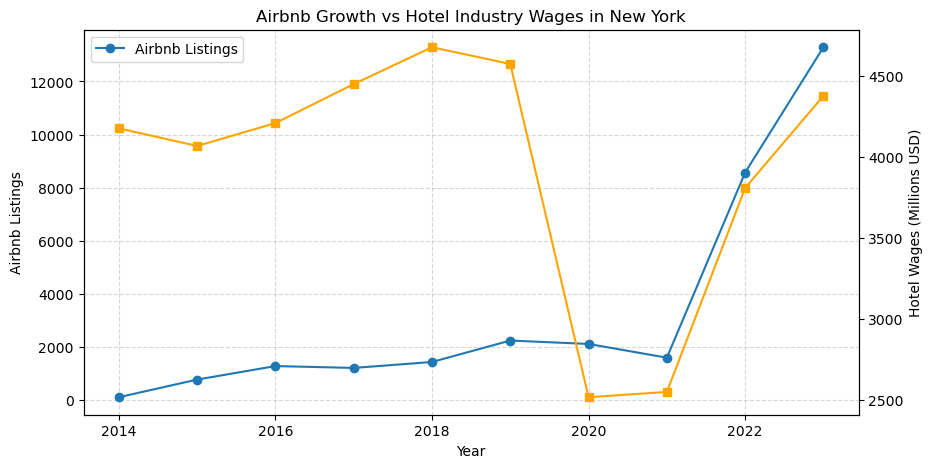

In [285]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

# Airbnb listings
ax1.plot(
    nyc_combined["year"],
    nyc_combined["airbnb_listings"],
    marker="o",
    label="Airbnb Listings"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Airbnb Listings")

# Second axis
ax2 = ax1.twinx()

ax2.plot(
    nyc_combined["year"],
    nyc_combined["hotel_wages_millions"],
    marker="s",
    color="orange",
    label="Hotel Wages"
)

ax2.set_ylabel("Hotel Wages (Millions USD)")

plt.title("Airbnb Growth vs Hotel Industry Wages in New York")

ax1.grid(True, linestyle="--", alpha=0.5)

ax1.legend(loc="upper left")

plt.show()

### New York — Airbnb Listings vs Hotel Industry Wages

This chart compares the growth of Airbnb listings in New York with total wages in the hotel industry (NAICS 72111) from 2014–2023.

Airbnb listings increased rapidly over time, especially after 2021, reflecting the expansion of short-term rental platforms in large urban markets. Hotel industry wages generally increased before 2020 but experienced a sharp decline during the COVID-19 pandemic.

Following the pandemic, hotel wages began recovering while Airbnb listings continued to grow quickly. This suggests that while Airbnb expanded significantly, broader economic events—such as the pandemic—played a major role in shaping hotel industry employment and wages.

Note: Airbnb yearly activity is approximated using the `last_review` date because listing creation timestamps are not available in the dataset.

## Los Angeles Airbnb vs Hotel Impact Analysis

In [289]:
la_airbnb = pd.read_csv("../raw/airbnb/Los Angeles/la-listings.csv")

la_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,770565020594037590,Phillips Ranch room with a view,30603612,Yamileth,Other Cities,Pomona,34.031856,-117.777994,Private room,61,5,1,2022-12-26,0.42,5,27,1,NaN
1,777451666060243581,Family oriented home,490709958,Dana,Unincorporated Areas,Castaic Canyons,34.439250,-118.444090,Private room,399,3,0,NaN,NaN,1,87,0,NaN
2,698097753730921190,方便易居驿站,444692513,Hanna,Other Cities,Pomona,34.048480,-117.768870,Private room,46,3,5,2023-01-16,0.86,4,87,5,NaN
3,13063118,TERRANEA OCEANFRNT 1BR CASITA -203 RSRT AMENIT...,41736985,Beth,Other Cities,Rancho Palos Verdes,33.738420,-118.395800,Private room,408,3,53,2022-11-26,0.64,10,270,13,NaN
4,39337076,Brand New Duplex Near World Cruise Center,208375458,Jae,Other Cities,Rancho Palos Verdes,33.748420,-118.311000,Private room,80,2,44,2023-02-24,1.09,4,357,26,NaN


In [291]:
la_airbnb["last_review"] = pd.to_datetime(la_airbnb["last_review"])

la_airbnb["year"] = la_airbnb["last_review"].dt.year

In [293]:
la_airbnb_clean = la_airbnb.dropna(subset=["year"])

la_airbnb_clean = la_airbnb_clean[["id","room_type","price","year"]]
la_airbnb_clean

,id,room_type,price,year
0,770565020594037590,Private room,61,2022.0
2,698097753730921190,Private room,46,2023.0
3,13063118,Private room,408,2022.0
4,39337076,Private room,80,2023.0
5,13077628,Entire home/apt,2138,2018.0
...,...,...,...,...
42446,17286704,Private room,40,2022.0
42447,751077061221390362,Private room,48,2023.0
42448,663030240787490751,Private room,46,2023.0
42449,15876540,Private room,68,2023.0


In [295]:
la_airbnb_yearly = (
    la_airbnb_clean.groupby("year")["id"]
    .count()
    .reset_index()
    .rename(columns={"id":"airbnb_listings"})
)
la_airbnb_yearly

,year,airbnb_listings
0,2011.0,1
1,2012.0,2
2,2013.0,6
3,2014.0,45
4,2015.0,222
5,2016.0,432
6,2017.0,511
7,2018.0,841
8,2019.0,1638
9,2020.0,1574


In [297]:
la_hotels = pd.read_excel("../raw/hotels/Los Angeles/hotels_wages_losangeles.xlsx", header=None)
la_hotels_clean = la_hotels.iloc[14:].copy()
la_hotels_clean.columns = ["year","q1","q2","q3","q4","hotel_wages"]
la_hotels_clean = la_hotels_clean[["year","hotel_wages"]]
la_hotels_clean = la_hotels_clean.apply(pd.to_numeric, errors="coerce").dropna()
la_hotels_clean

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,year,hotel_wages
14,2014,2223452
15,2015,2377526
16,2016,2521225
17,2017,2652781
18,2018,2830935
19,2019,2988527
20,2020,1841907
21,2021,2048336
22,2022,3040194
23,2023,3482382


In [299]:
la_combined = pd.merge(
    la_airbnb_yearly,
    la_hotels_clean,
    on="year",
    how="inner"
)
la_combined

,year,airbnb_listings,hotel_wages
0,2014.0,45,2223452
1,2015.0,222,2377526
2,2016.0,432,2521225
3,2017.0,511,2652781
4,2018.0,841,2830935
5,2019.0,1638,2988527
6,2020.0,1574,1841907
7,2021.0,1799,2048336
8,2022.0,8714,3040194
9,2023.0,14995,3482382


In [301]:
la_combined["hotel_wages_millions"] = la_combined["hotel_wages"] / 1000

In [303]:
plt.style.use("seaborn-v0_8")

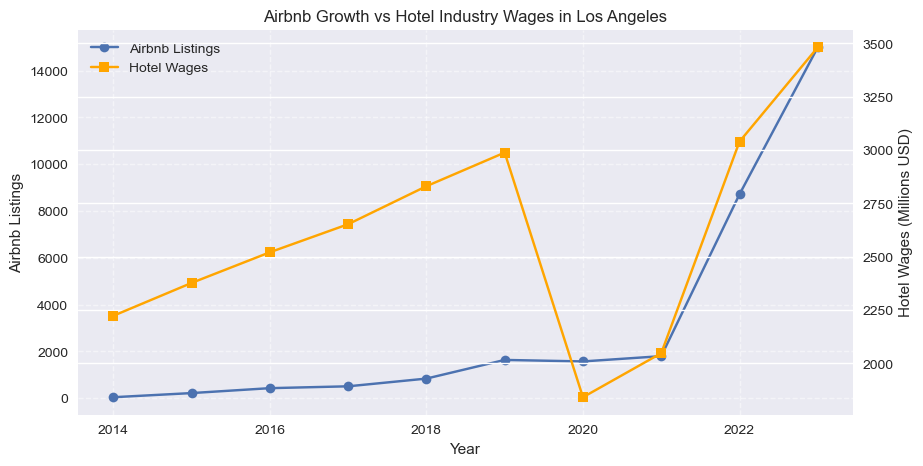

In [305]:
fig, ax1 = plt.subplots(figsize=(10,5))

line1 = ax1.plot(
    la_combined["year"],
    la_combined["airbnb_listings"],
    marker="o",
    label="Airbnb Listings"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Airbnb Listings")

ax2 = ax1.twinx()

line2 = ax2.plot(
    la_combined["year"],
    la_combined["hotel_wages_millions"],
    marker="s",
    color="orange",
    label="Hotel Wages"
)

ax2.set_ylabel("Hotel Wages (Millions USD)")

plt.title("Airbnb Growth vs Hotel Industry Wages in Los Angeles")

lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="upper left")

ax1.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Los Angeles Analysis

The Los Angeles case study shows a clear increase in Airbnb listings over time, especially after 2021. The number of short-term rental listings grew rapidly as the platform expanded in the city.

Hotel industry wages increased gradually between 2014 and 2019, indicating stable growth in the traditional hospitality sector. However, a sharp decline is visible around 2020, which aligns with the economic disruption caused by the COVID-19 pandemic.

Following 2021, both Airbnb listings and hotel wages began to recover. The strong growth in Airbnb listings suggests increasing adoption of short-term rental platforms in the Los Angeles market.

While the data does not establish a direct causal relationship, the comparison highlights how rapidly the short-term rental market has expanded alongside fluctuations in the traditional hotel industry.


## San Francisco Airbnb vs Hotel Impact Analysis

In [309]:
sf_airbnb = pd.read_csv("../raw/airbnb/San Francisco/sf-listings.csv")
sf_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",1169,Holly,NaN,Western Addition,37.77028,-122.43317,Entire home/apt,202,2,383,2023-02-19,2.31,1,128,59,City Registration Pending
1,5858,Creative Sanctuary,8904,Philip And Tania,NaN,Bernal Heights,37.74474,-122.42089,Entire home/apt,235,30,111,2017-08-06,0.66,1,365,0,NaN
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,NaN,Haight Ashbury,37.76555,-122.45213,Private room,56,32,9,2022-10-27,0.09,13,365,1,NaN
3,8339,Historic Alamo Square Victorian,24215,Rosy,NaN,Western Addition,37.77564,-122.43642,Entire home/apt,575,9,28,2019-06-28,0.17,2,365,0,STR-0000264
4,8739,"Mission Sunshine, with Private Bath",7149,Ivan & Wendy,NaN,Mission,37.76030,-122.42197,Private room,110,1,770,2023-02-25,4.65,2,159,34,STR-0000028


In [311]:
sf_airbnb["last_review"] = pd.to_datetime(sf_airbnb["last_review"])
sf_airbnb["year"] = sf_airbnb["last_review"].dt.year

In [313]:
sf_airbnb_clean = sf_airbnb.dropna(subset=["year"])
sf_airbnb_clean = sf_airbnb_clean[["id","room_type","price","year"]]
sf_airbnb_clean

,id,room_type,price,year
0,958,Entire home/apt,202,2023.0
1,5858,Entire home/apt,235,2017.0
2,8142,Private room,56,2022.0
3,8339,Entire home/apt,575,2019.0
4,8739,Private room,110,2023.0
...,...,...,...,...
6867,825556652890829322,Private room,39,2023.0
6869,826084732393425639,Entire home/apt,524,2023.0
6871,826247339723555403,Entire home/apt,120,2023.0
6905,838436486814441342,Entire home/apt,514,2023.0


In [315]:
sf_airbnb_yearly = (
    sf_airbnb_clean.groupby("year")["id"]
    .count()
    .reset_index()
    .rename(columns={"id":"airbnb_listings"})
)
sf_airbnb_yearly.head(15)

,year,airbnb_listings
0,2010.0,1
1,2011.0,1
2,2012.0,2
3,2013.0,3
4,2014.0,15
5,2015.0,22
6,2016.0,50
7,2017.0,68
8,2018.0,103
9,2019.0,219


In [317]:
sf_hotels = pd.read_excel("../raw/hotels/San Francisco/hotels_wages_sanfrancisco.xlsx", header=None)
sf_hotels_clean = sf_hotels.iloc[14:].copy()
sf_hotels_clean.columns = ["year","q1","q2","q3","q4","hotel_wages"]
sf_hotels_clean = sf_hotels_clean[["year","hotel_wages"]]
sf_hotels_clean = sf_hotels_clean.apply(pd.to_numeric, errors="coerce").dropna()
sf_hotels_clean

C:\Users\user\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,year,hotel_wages
14,2014,1203822.0
15,2015,1288208.0
22,2022,1200321.0
23,2023,1399920.0


In [319]:
sf_combined = pd.merge(
    sf_airbnb_yearly,
    sf_hotels_clean,
    on="year",
    how="inner"
)
sf_combined

,year,airbnb_listings,hotel_wages
0,2014.0,15,1203822.0
1,2015.0,22,1288208.0
2,2022.0,1984,1200321.0
3,2023.0,2578,1399920.0


In [321]:
sf_combined["hotel_wages_millions"] = sf_combined["hotel_wages"] / 1000
sf_combined = sf_combined.sort_values("year")

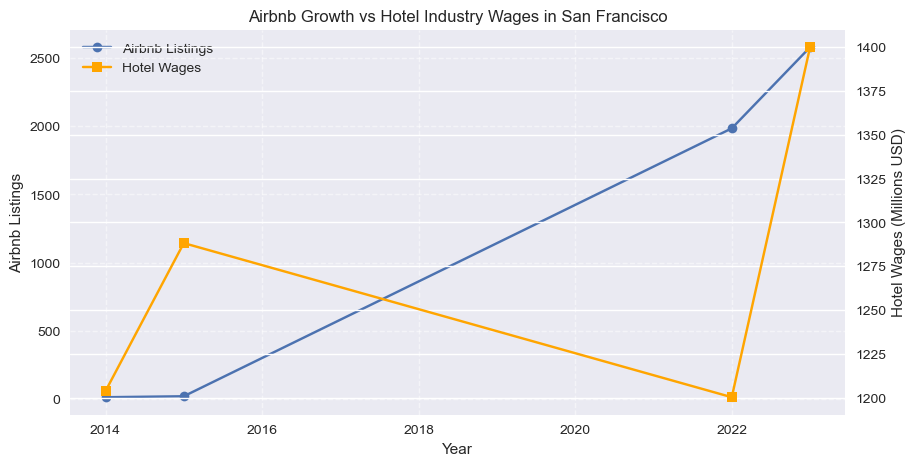

In [323]:
fig, ax1 = plt.subplots(figsize=(10,5))

line1 = ax1.plot(
    sf_combined["year"],
    sf_combined["airbnb_listings"],
    marker="o",
    label="Airbnb Listings"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Airbnb Listings")

ax2 = ax1.twinx()

line2 = ax2.plot(
    sf_combined["year"],
    sf_combined["hotel_wages_millions"],
    marker="s",
    color="orange",
    label="Hotel Wages"
)

ax2.set_ylabel("Hotel Wages (Millions USD)")

plt.title("Airbnb Growth vs Hotel Industry Wages in San Francisco")

lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="upper left")

ax1.grid(True, linestyle="--", alpha=0.5)

plt.show()

### San Francisco Analysis

San Francisco is a particularly important case study because Airbnb was originally founded in this city. The available data shows a noticeable increase in Airbnb listings between 2014 and 2023.

Due to limited hotel wage data for this region, only a few overlapping years are available for comparison. Despite this limitation, the data still highlights strong growth in Airbnb listings over time while hotel wages show variation across the observed years.

Although the dataset is limited, the trend reflects the rapid expansion of the short-term rental market in San Francisco, one of Airbnb’s most influential markets.


In [326]:
chi_combined = chi_combined.rename(columns={
    "listing_count": "airbnb_listings",
    "hotel_wages_thousands": "hotel_wages"
})

chi_combined = chi_combined[["year","airbnb_listings","hotel_wages"]]
chi_combined["city"] = "Chicago"

In [328]:
seattle_combined = seattle_combined.rename(columns={
    "listing_count": "airbnb_listings",
    "hotel_wages_thousands": "hotel_wages"
})

seattle_combined = seattle_combined[["year","airbnb_listings","hotel_wages"]]
seattle_combined["city"] = "Seattle"

In [330]:
nyc_combined = nyc_combined.rename(columns={
    "listing_count": "airbnb_listings",
    "hotel_wages_thousands": "hotel_wages"
})

nyc_combined = nyc_combined[["year","airbnb_listings","hotel_wages"]]
nyc_combined["city"] = "New York"

In [332]:
sf_combined = sf_combined.rename(columns={
    "listing_count": "airbnb_listings",
    "hotel_wages_thousands": "hotel_wages"
})

sf_combined = sf_combined[["year","airbnb_listings","hotel_wages"]]
sf_combined["city"] = "San Francisco"

In [334]:
la_combined = la_combined.rename(columns={
    "listing_count": "airbnb_listings",
    "hotel_wages_thousands": "hotel_wages"
})

la_combined = la_combined[["year","airbnb_listings","hotel_wages"]]
la_combined["city"] = "Los Angeles"

In [336]:
df = pd.concat([
    chi_combined,
    seattle_combined,
    nyc_combined,
    la_combined,
    sf_combined
], ignore_index=True)

df["hotel_wages_millions"] = df["hotel_wages"] / 1000

df

,year,airbnb_listings,hotel_wages,city,hotel_wages_millions
0,2014.0,1,1252848.0,Chicago,1252.848
1,2015.0,4,1449243.0,Chicago,1449.243
2,2016.0,20,1454926.0,Chicago,1454.926
3,2017.0,38,1514772.0,Chicago,1514.772
4,2018.0,73,1598462.0,Chicago,1598.462
5,2019.0,158,1692781.0,Chicago,1692.781
6,2020.0,192,869722.0,Chicago,869.722
7,2021.0,297,982423.0,Chicago,982.423
8,2022.0,1950,1499942.0,Chicago,1499.942
9,2023.0,3521,1692234.0,Chicago,1692.234


In [338]:
df.to_csv("final_airbnb_hotel_dataset.csv", index=False)

## Conclusion

This analysis explored the relationship between the growth of Airbnb listings and hotel industry wages across major U.S. cities from 2014 to 2023.

The results show that Airbnb listings have increased significantly over the past decade, particularly after 2021, when short-term rentals experienced rapid growth across cities such as Chicago, Los Angeles, and New York. Despite this growth, the hotel industry did not experience a long-term decline in wages. Instead, hotel wages generally increased over time, indicating that the hotel sector continued to grow alongside the expansion of Airbnb.

A noticeable disruption occurred in 2020 due to the COVID-19 pandemic, when hotel wages dropped sharply across most cities. However, both Airbnb listings and hotel wages recovered in the following years, suggesting that the hospitality industry adapted to changing market conditions.

Overall, the findings suggest that Airbnb has not replaced the traditional hotel industry but rather coexists within the broader accommodation ecosystem. Both sectors appear to serve different segments of the travel market and can grow simultaneously.

Future work could include analyzing additional factors such as tourism demand, hotel occupancy rates, local regulations on short-term rentals, and seasonal trends to further understand the dynamics between Airbnb and traditional hotels.

## Interactive Dashboard

An interactive dashboard was developed using **Plotly Dash** to explore the relationship between Airbnb listings and hotel industry wages across multiple cities.

The dashboard allows users to select a city from a dropdown menu and visualize trends over time, providing an intuitive way to compare Airbnb growth and hotel industry wages.

The dashboard implementation can be found in the `dashboard/` folder of this project.